> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Normality Check
3. **LSTM with RobustScaler** – Preprocess → Split → Sequences → Build/Train → Predict → Visualize → Evaluate
4. **LSTM with MinMaxScaler** – Preprocess → Split → Sequences → Build/Train → Predict → Visualize → Evaluate

# 1. Fetching Stock Data

In [30]:
import yfinance as yf

# Historical data fetching (Tesla)
stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-03-23,380.850006,385.329987,372.730011,373.089996,74606000
2026-03-24,383.029999,387.480011,376.309998,376.559998,60004900
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300


# 2. Normality Check

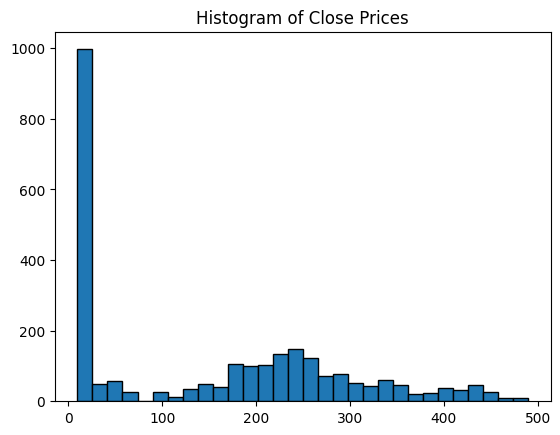

Shapiro-Wilk p-value: 4.79919580136373e-42
Data not normal -> consider RobustScaler or MinMaxScaler.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Create target (Close column)
target_data = stock_data['Close'].values

# Histogram
plt.hist(target_data, bins=30, edgecolor='black')
plt.title("Histogram of Close Prices")
plt.show()

# Shapiro-Wilk test
stat, p = shapiro(target_data)
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Data looks normal -> StandardScaler is fine.")
else:
    print("Data not normal -> consider RobustScaler or MinMaxScaler.")

---
# 3. LSTM with RobustScaler

## 3.1 Preprocessing (RobustScaler)

In [32]:
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
scaled_target_robust = scaler_robust.fit_transform(target_data.reshape(-1, 1))

## 3.2 Splitting (RobustScaler)

In [33]:
train_size_robust = int(len(scaled_target_robust) * 0.8)
train_robust, test_robust = scaled_target_robust[:train_size_robust], scaled_target_robust[train_size_robust:]

## 3.3 Data Preparation for LSTM (RobustScaler)

In [34]:
def create_sequences(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

seq_len = 60  # last 60 days to predict next day's price

x_train_r, y_train_r = create_sequences(train_robust, seq_len=seq_len)
x_test_r, y_test_r = create_sequences(test_robust, seq_len=seq_len)

# Reshape to be compatible with LSTM
x_train_r = np.reshape(x_train_r, (x_train_r.shape[0], x_train_r.shape[1], 1))
x_test_r = np.reshape(x_test_r, (x_test_r.shape[0], x_test_r.shape[1], 1))

## 3.4 Building and Training LSTM (RobustScaler)

In [35]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input

model_robust = Sequential()
model_robust.add(Input(shape=(60, 1)))
model_robust.add(LSTM(units=100, return_sequences=True))
model_robust.add(Dropout(0.2))
model_robust.add(LSTM(units=100, return_sequences=False))
model_robust.add(Dropout(0.2))
model_robust.add(Dense(units=1))

model_robust.compile(optimizer='adam', loss='mean_squared_error')
model_robust.fit(x_train_r, y_train_r, epochs=20, batch_size=32)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0199
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0043
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0039
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0036
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0035
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 0.0032
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0032
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0029
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 0.0027
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0029
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0026
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 0.0026
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0025
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - loss: 0.0025
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - loss: 0.00

## 3.5 Making Prediction (RobustScaler)

In [36]:
prediction_robust = model_robust.predict(x_test_r)
prediction_robust = scaler_robust.inverse_transform(prediction_robust)
y_test_robust_actual = scaler_robust.inverse_transform(y_test_r.reshape(-1, 1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step


## 3.6 Visualization (RobustScaler)

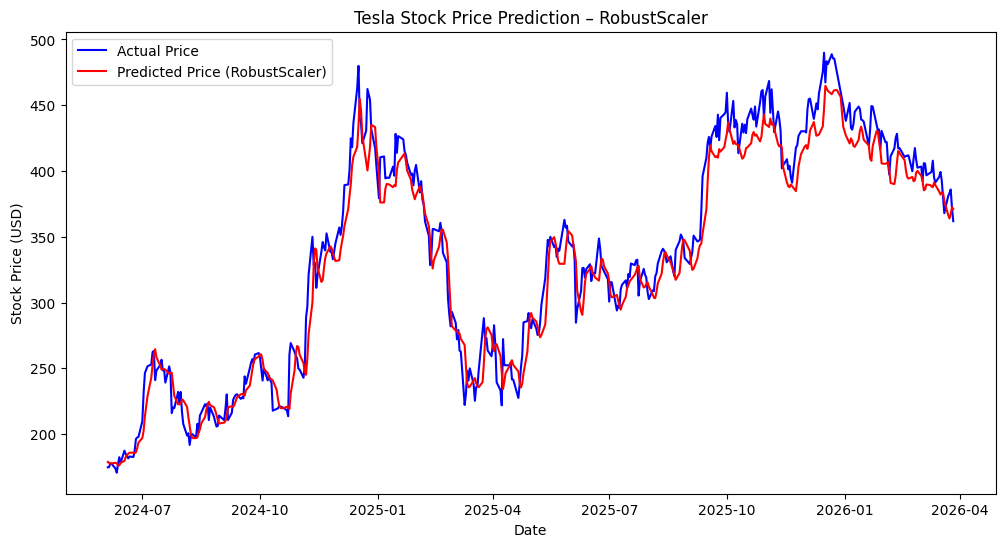

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index[-len(y_test_r):], y_test_robust_actual.flatten(), label='Actual Price', color='blue')
plt.plot(stock_data.index[-len(x_test_r):], prediction_robust.flatten(), label='Predicted Price (RobustScaler)', color='red')
plt.title('Tesla Stock Price Prediction – RobustScaler')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

## 3.7 Model Evaluation (RobustScaler)

In [38]:
from sklearn.metrics import mean_squared_error

mse_robust = mean_squared_error(y_test_robust_actual, prediction_robust)
rmse_robust = np.sqrt(mse_robust)

print(f'[RobustScaler] Mean Squared Error: {mse_robust}')
print(f'[RobustScaler] Root Mean Squared Error: {rmse_robust}')

[RobustScaler] Mean Squared Error: 304.65789764276553
[RobustScaler] Root Mean Squared Error: 17.454452086581394


---
# 4. LSTM with MinMaxScaler

## 4.1 Preprocessing (MinMaxScaler)

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
scaled_target_minmax = scaler_minmax.fit_transform(target_data.reshape(-1, 1))

## 4.2 Splitting (MinMaxScaler)

In [40]:
train_size_minmax = int(len(scaled_target_minmax) * 0.8)
train_minmax, test_minmax = scaled_target_minmax[:train_size_minmax], scaled_target_minmax[train_size_minmax:]

## 4.3 Data Preparation for LSTM (MinMaxScaler)

In [41]:
x_train_m, y_train_m = create_sequences(train_minmax, seq_len=seq_len)
x_test_m, y_test_m = create_sequences(test_minmax, seq_len=seq_len)

# Reshape to be compatible with LSTM
x_train_m = np.reshape(x_train_m, (x_train_m.shape[0], x_train_m.shape[1], 1))
x_test_m = np.reshape(x_test_m, (x_test_m.shape[0], x_test_m.shape[1], 1))

## 4.4 Building and Training LSTM (MinMaxScaler)

In [42]:
model_minmax = Sequential()
model_minmax.add(Input(shape=(60, 1)))
model_minmax.add(LSTM(units=100, return_sequences=True))
model_minmax.add(Dropout(0.2))
model_minmax.add(LSTM(units=100, return_sequences=False))
model_minmax.add(Dropout(0.2))
model_minmax.add(Dense(units=1))

model_minmax.compile(optimizer='adam', loss='mean_squared_error')
model_minmax.fit(x_train_m, y_train_m, epochs=20, batch_size=32)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0058
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - loss: 0.0013
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0013
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - loss: 0.0011
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 0.0012
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.0011
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 0.0011
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - loss: 8.2507e-04
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 9.4063e-04
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 9.8069e-04
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 7.0539e-04
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 7.4401e-04
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 7.7754e-04
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - loss: 8.3646e-04
Epoch 15/20
63/63 ━━━━━━━━━━

## 4.5 Making Prediction (MinMaxScaler)

In [43]:
prediction_minmax = model_minmax.predict(x_test_m)
prediction_minmax = scaler_minmax.inverse_transform(prediction_minmax)
y_test_minmax_actual = scaler_minmax.inverse_transform(y_test_m.reshape(-1, 1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step


## 4.6 Visualization (MinMaxScaler)

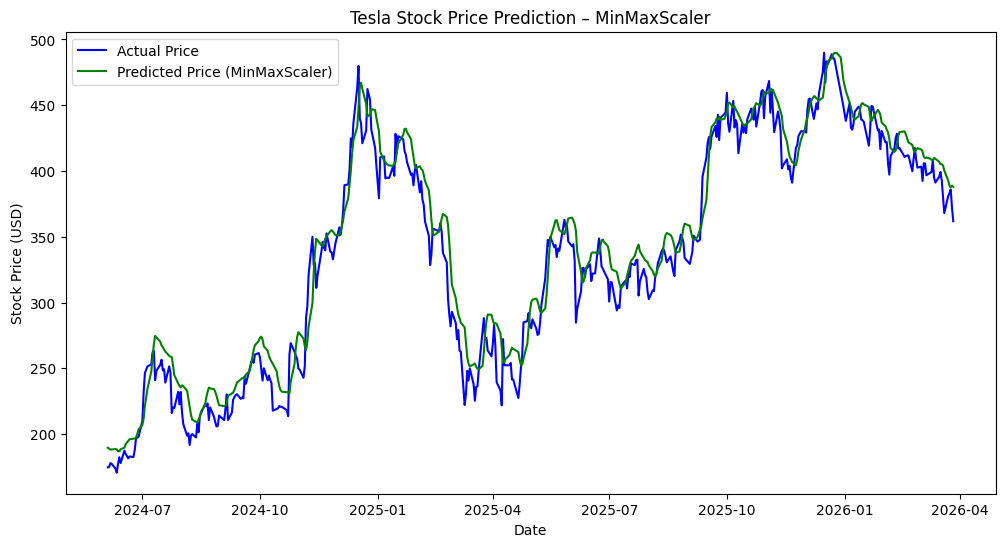

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index[-len(y_test_m):], y_test_minmax_actual.flatten(), label='Actual Price', color='blue')
plt.plot(stock_data.index[-len(x_test_m):], prediction_minmax.flatten(), label='Predicted Price (MinMaxScaler)', color='green')
plt.title('Tesla Stock Price Prediction – MinMaxScaler')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

## 4.7 Model Evaluation (MinMaxScaler)

In [45]:
mse_minmax = mean_squared_error(y_test_minmax_actual, prediction_minmax)
rmse_minmax = np.sqrt(mse_minmax)

print(f'[MinMaxScaler] Mean Squared Error: {mse_minmax}')
print(f'[MinMaxScaler] Root Mean Squared Error: {rmse_minmax}')

[MinMaxScaler] Mean Squared Error: 347.9058519347525
[MinMaxScaler] Root Mean Squared Error: 18.65223450245982


---
# 5. Side-by-Side Comparison

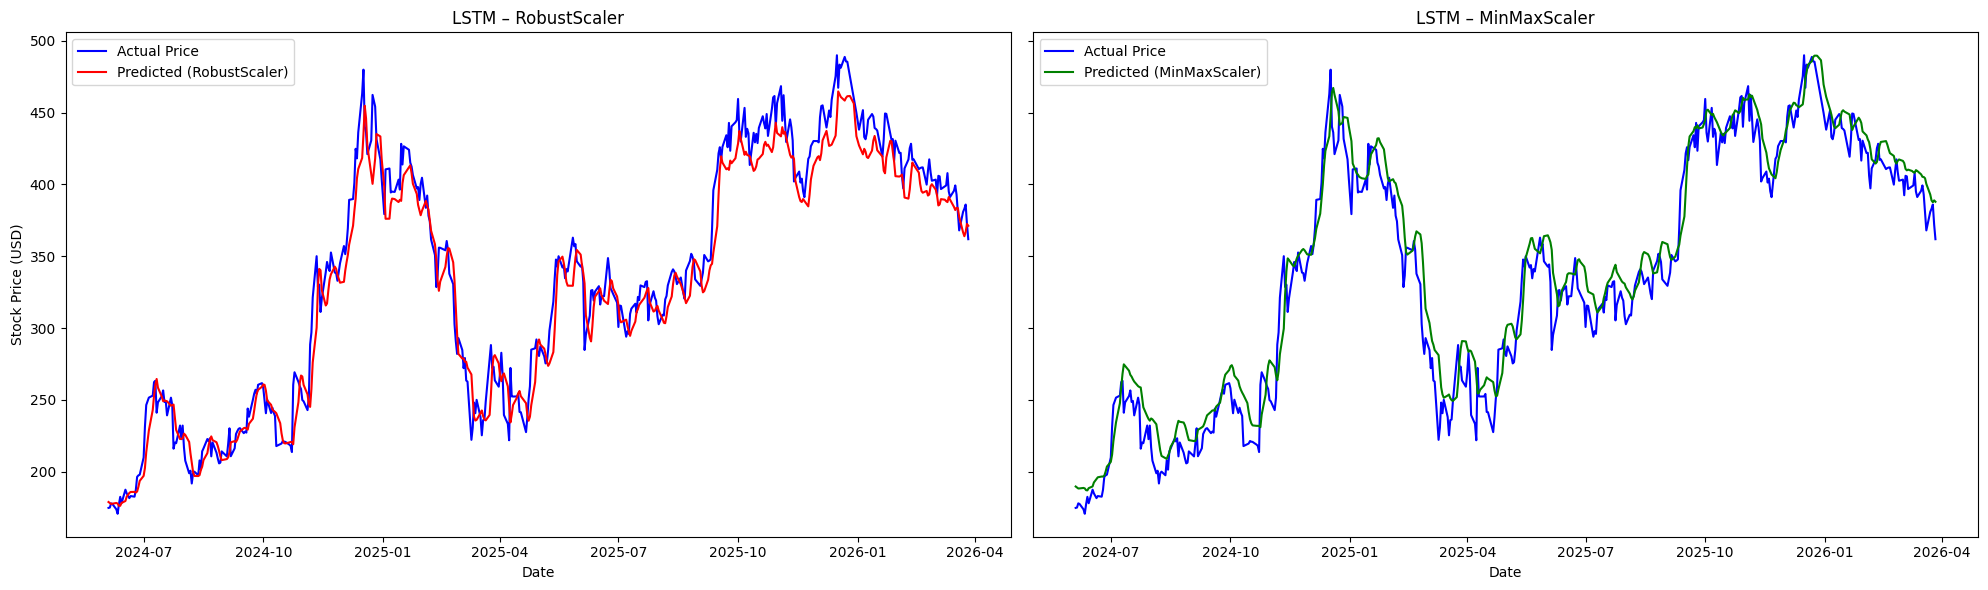

Scaler                        MSE         RMSE
RobustScaler             304.6579      17.4545
MinMaxScaler             347.9059      18.6522


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# RobustScaler plot
axes[0].plot(stock_data.index[-len(y_test_r):], y_test_robust_actual.flatten(), label='Actual Price', color='blue')
axes[0].plot(stock_data.index[-len(x_test_r):], prediction_robust.flatten(), label='Predicted (RobustScaler)', color='red')
axes[0].set_title('LSTM – RobustScaler')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Stock Price (USD)')
axes[0].legend()

# MinMaxScaler plot
axes[1].plot(stock_data.index[-len(y_test_m):], y_test_minmax_actual.flatten(), label='Actual Price', color='blue')
axes[1].plot(stock_data.index[-len(x_test_m):], prediction_minmax.flatten(), label='Predicted (MinMaxScaler)', color='green')
axes[1].set_title('LSTM – MinMaxScaler')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

print('=' * 50)
print(f'{"Scaler":<20} {"MSE":>12} {"RMSE":>12}')
print('=' * 50)
print(f'{"RobustScaler":<20} {mse_robust:>12.4f} {rmse_robust:>12.4f}')
print(f'{"MinMaxScaler":<20} {mse_minmax:>12.4f} {rmse_minmax:>12.4f}')
print('=' * 50)